**Лабораторна робота №4**

Імпортуємо необхідні бібліотеки

In [1]:
!pip install kaggle opendatasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn бібліотеки
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             matthews_corrcoef, classification_report)
from sklearn.inspection import permutation_importance

Налаштовуємо візуалізацію.

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Завантажуємо датасет і проводимо його первинний аналіз.

In [3]:
df = pd.read_csv('synthetic_coffee_health_10000.csv')

print(f"\nРозмір датасету: {df.shape[0]} рядків × {df.shape[1]} стовпців")
print(f"\nПерші 5 записів:")
print(df.head())
print(f"\nІнформація про типи даних:")
print(df.info())
print(f"\nСтатистичний опис:")
print(df.describe())
print(f"\nПропущені значення:")
print(df.isnull().sum())
print(f"\nРозподіл цільової змінної Health_Issues:")
print(df['Health_Issues'].value_counts())


Розмір датасету: 10000 рядків × 16 стовпців

Перші 5 записів:
   ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0   1   40    Male  Germany            3.5        328.1          7.5   
1   2   33    Male  Germany            1.0         94.1          6.2   
2   3   42    Male   Brazil            5.3        503.7          5.9   
3   4   53    Male  Germany            2.6        249.2          7.3   
4   5   32  Female    Spain            3.1        298.0          5.3   

  Sleep_Quality   BMI  Heart_Rate Stress_Level  Physical_Activity_Hours  \
0          Good  24.9          78          Low                     14.5   
1          Good  20.0          67          Low                     11.0   
2          Fair  22.7          59       Medium                     11.2   
3          Good  24.7          71          Low                      6.6   
4          Fair  24.1          76       Medium                      8.5   

  Health_Issues Occupation  Smoking  Alcohol_Consumpt

Проводимо попередню обробку даних. Видаляємо ID колонку.

In [4]:
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
    print("Видалено колонку ID")

Видалено колонку ID


Перевіряємо наявність пропусків.

In [5]:
if df.isnull().sum().sum() > 0:
    print("Виявлено пропущені значення. Заповнюємо медіаною/модою...")
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)

Виявлено пропущені значення. Заповнюємо медіаною/модою...


Розділяємо ознаки та цільову змінну і кодуємо останню.

In [6]:
X = df.drop('Health_Issues', axis=1)
y = df['Health_Issues']

# Кодуємо цільову змінну
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"\nЦільова змінна закодована: {dict(enumerate(le_target.classes_))}")


Цільова змінна закодована: {0: 'Mild', 1: 'Moderate', 2: 'Severe'}


Визначаємо категоріальні та числові ознаки.

In [7]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nКатегоріальні ознаки ({len(categorical_cols)}): {categorical_cols}")
print(f"Числові ознаки ({len(numerical_cols)}): {numerical_cols}")


Категоріальні ознаки (5): ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation']
Числові ознаки (9): ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption']


Кодуємо категоріальні ознаки через one-hot encoding.

In [8]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
print(f"\nOne-hot encoding виконано. Нова кількість ознак: {X_encoded.shape[1]}")

# Зберігаємо назви ознак
feature_names = X_encoded.columns.tolist()


One-hot encoding виконано. Нова кількість ознак: 44


Розділяємо датасет на тренувальні та тестові дані.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded.values, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nДані розділено:")
print(f"  Тренувальна вибірка: {X_train.shape[0]} зразків")
print(f"  Тестова вибірка: {X_test.shape[0]} зразків")


Дані розділено:
  Тренувальна вибірка: 8000 зразків
  Тестова вибірка: 2000 зразків


 Додатково створюємо валідаційну вибірку для прунінгу.

In [10]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"  Вибірка для навчання (після виділення валідації): {X_train_sub.shape[0]} зразків")
print(f"  Валідаційна вибірка (для прунінгу): {X_val.shape[0]} зразків")

  Вибірка для навчання (після виділення валідації): 6400 зразків
  Валідаційна вибірка (для прунінгу): 1600 зразків


Власна реалізація дерева рішень з використанням Gini Index. Включає обчислення feature importance.

In [11]:
class MyDecisionTree:
    def __init__(self, max_depth=5, min_samples=2, min_impurity=1e-7):
        """
        Параметри:
        - max_depth: максимальна глибина дерева
        - min_samples: мінімальна кількість зразків для розділу
        - min_impurity: мінімальне зменшення impurity для розділу
        """
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.min_impurity = min_impurity
        self.feature_importance = None
        self.tree = None
        self.n_features = None
        self.n_classes = None

    def gini(self, y):
        """
        Обчислює Gini impurity для масиву міток класів.

        Gini = 1 - Σ(p_i²), де p_i - частка класу i
        """
        if len(y) == 0:
            return 0

        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities ** 2)
        return gini

    def best_split(self, X, y):
        """
        Знаходить найкращий розділ за всіма ознаками та порогами.
        Повертає: (найкраща_ознака, найкращий_поріг, найкраща_gini, зменшення_gini)
        """
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        best_gini_decrease = 0

        current_gini = self.gini(y)
        n_samples = len(y)

        # Перебираємо всі ознаки
        for feature in range(X.shape[1]):
            # Отримуємо унікальні значення ознаки як можливі пороги
            thresholds = np.unique(X[:, feature])

            # Перебираємо всі пороги
            for threshold in thresholds:
                # Розділяємо дані
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                # Пропускаємо, якщо одна з груп порожня
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                # Обчислюємо Gini для лівого та правого піддерев
                y_left = y[left_mask]
                y_right = y[right_mask]

                gini_left = self.gini(y_left)
                gini_right = self.gini(y_right)

                # Обчислюємо зважену Gini після розділу
                n_left = len(y_left)
                n_right = len(y_right)
                weighted_gini = (n_left / n_samples) * gini_left + \
                                (n_right / n_samples) * gini_right

                # Оновлюємо найкращий розділ
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold
                    best_gini_decrease = current_gini - weighted_gini

        return best_feature, best_threshold, best_gini, best_gini_decrease

    def build_tree(self, X, y, depth=0):
        """
        Рекурсивно будує дерево рішень.
        """
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # Визначаємо majority class
        classes, counts = np.unique(y, return_counts=True)
        majority_class = classes[np.argmax(counts)]

        # Критерії зупинки
        if (depth >= self.max_depth or
            n_samples < self.min_samples or
            n_classes == 1 or
            self.gini(y) < self.min_impurity):
            return {
                'leaf': True,
                'class': majority_class,
                'n_samples': n_samples,
                'gini': self.gini(y)
            }

        # Знаходимо найкращий розділ
        feature, threshold, gini_after, gini_decrease = self.best_split(X, y)

        # Якщо не знайдено хороший розділ
        if feature is None:
            return {
                'leaf': True,
                'class': majority_class,
                'n_samples': n_samples,
                'gini': self.gini(y)
            }

        # Оновлюємо важливість ознаки
        # Важливість = (n_samples / n_total) * gini_decrease
        importance_value = (n_samples / self.n_total) * gini_decrease
        self.feature_importance[feature] += importance_value

        # Розділяємо дані
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        # Рекурсивно будуємо піддерева
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree,
            'n_samples': n_samples,
            'gini': self.gini(y),
            'class': majority_class
        }

    def fit(self, X, y):
        """
        Навчає дерево та обчислює нормалізовану важливість ознак.
        """
        self.n_features = X.shape[1]
        self.n_classes = len(np.unique(y))
        self.n_total = len(y)
        self.feature_importance = np.zeros(self.n_features)

        # Будуємо дерево
        self.tree = self.build_tree(X, y)

        # Нормалізуємо важливість
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)

        return self

    def predict_one(self, x, node):
        """
        Прогнозує клас для одного зразка, проходячи по дереву.
        """
        if node['leaf']:
            return node['class']

        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        """
        Прогнозує класи для всіх зразків.
        """
        return np.array([self.predict_one(x, self.tree) for x in X])

    def count_leaves(self, node=None):
        """
        Підраховує кількість листів у дереві.
        """
        if node is None:
            node = self.tree

        if node['leaf']:
            return 1

        return self.count_leaves(node['left']) + self.count_leaves(node['right'])

    def get_depth(self, node=None):
        """
        Обчислює глибину дерева.
        """
        if node is None:
            node = self.tree

        if node['leaf']:
            return 1

        return 1 + max(self.get_depth(node['left']), self.get_depth(node['right']))

    def score(self, X, y):
        """
        Обчислює accuracy score для sklearn сумісності.
        Потрібно для permutation_importance.
        """
        predictions = self.predict(X)
        return np.mean(predictions == y)

Створюємо та навчаємо дерево.

In [12]:
start_time = time.time()
my_tree = MyDecisionTree(max_depth=10, min_samples=10)
my_tree.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"\nДерево навчено за {train_time:.4f} секунд")
print(f"  Глибина дерева: {my_tree.get_depth()}")
print(f"  Кількість листів: {my_tree.count_leaves()}")


Дерево навчено за 3.9621 секунд
  Глибина дерева: 6
  Кількість листів: 9


Прогнозуємо.

In [13]:
start_time = time.time()
y_pred_my = my_tree.predict(X_test)
predict_time = time.time() - start_time

print(f"  Час прогнозування: {predict_time:.4f} секунд")

  Час прогнозування: 0.0015 секунд


Обчислюємо метрики.

In [14]:
accuracy_my = accuracy_score(y_test, y_pred_my)
f1_my = f1_score(y_test, y_pred_my, average='weighted')
mcc_my = matthews_corrcoef(y_test, y_pred_my)
cm_my = confusion_matrix(y_test, y_pred_my)

print(f"\nМЕТРИКИ:")
print(f"  Accuracy: {accuracy_my:.4f}")
print(f"  F1-Score (weighted): {f1_my:.4f}")
print(f"  MCC: {mcc_my:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_my,
                          target_names=le_target.classes_))


МЕТРИКИ:
  Accuracy: 0.9980
  F1-Score (weighted): 0.9980
  MCC: 0.9788

Classification Report:
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00      1904
    Moderate       0.96      1.00      0.98        93
      Severe       1.00      1.00      1.00         3

    accuracy                           1.00      2000
   macro avg       0.99      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000



Виводимо матрицю невідповідностей.

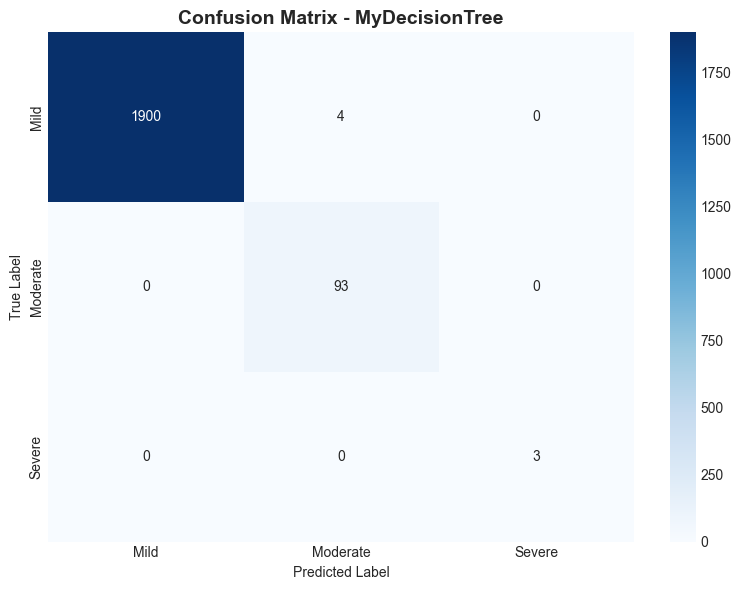

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_my, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - MyDecisionTree', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Візуалізація важливості ознак.

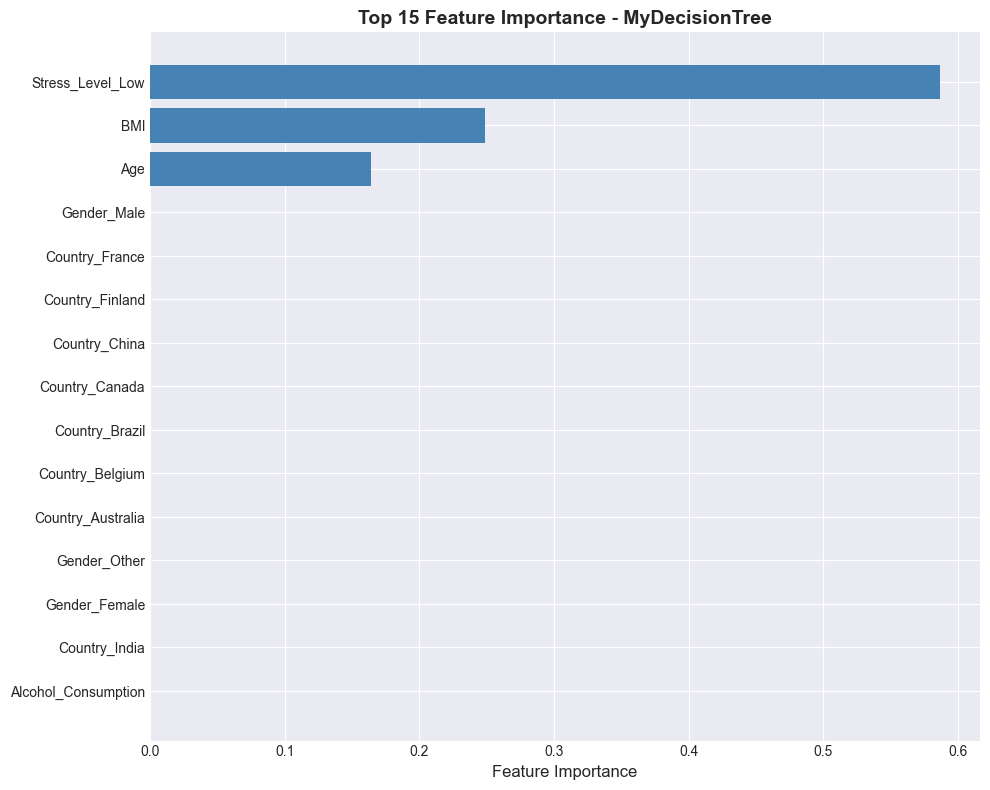

In [16]:
top_n = 15
indices = np.argsort(my_tree.feature_importance)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), my_tree.feature_importance[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Top {top_n} Feature Importance - MyDecisionTree',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Реалізація прунінгу (Cost-Complexity Pruning).

In [17]:
class MyDecisionTreeWithPruning(MyDecisionTree):
    def calculate_error(self, X, y, node):
        """
        Обчислює помилку на валідаційних даних для даного вузла.
        """
        if node['leaf']:
            predictions = np.full(len(y), node['class'])
            return np.sum(predictions != y)

        # Для не-листового вузла потрібно пройти по дереву
        errors = 0
        for i, x in enumerate(X):
            pred = self.predict_one(x, node)
            if pred != y[i]:
                errors += 1
        return errors

    def prune_tree(self, node, alpha, validation_X, validation_y):
        """
        Рекурсивно обрізає дерево на основі cost-complexity критерію.
        """
        if node['leaf']:
            return self.calculate_error(validation_X, validation_y, node)

        # Рекурсивно обробляємо піддерева
        left_error = self.prune_tree(node['left'], alpha, validation_X, validation_y)
        right_error = self.prune_tree(node['right'], alpha, validation_X, validation_y)

        # Помилка піддерева
        subtree_error = left_error + right_error
        subtree_leaves = self.count_leaves(node)

        # Помилка якщо перетворити вузол на лист
        leaf_node = {'leaf': True, 'class': node['class'],
                     'n_samples': node['n_samples'], 'gini': node['gini']}
        leaf_error = self.calculate_error(validation_X, validation_y, leaf_node)

        # Cost-complexity критерій
        subtree_cost = subtree_error + alpha * subtree_leaves
        leaf_cost = leaf_error + alpha

        # Якщо перетворення на лист краще, робимо прунінг
        if leaf_cost <= subtree_cost:
            node['leaf'] = True
            if 'left' in node:
                del node['left']
            if 'right' in node:
                del node['right']
            if 'feature' in node:
                del node['feature']
            if 'threshold' in node:
                del node['threshold']
            return leaf_error

        return subtree_error

    def apply_pruning(self, validation_X, validation_y, alpha=0.01):
        """
        Застосовує прунінг до навченого дерева.
        """
        self.prune_tree(self.tree, alpha, validation_X, validation_y)

        # Переобчислюємо важливість ознак після прунінгу
        self.feature_importance = np.zeros(self.n_features)
        self._recalculate_importance(self.tree)

        # Нормалізуємо
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)

        return self

    def _recalculate_importance(self, node, depth=0):
        """
        Рекурсивно переобчислює важливість ознак після прунінгу.
        """
        if node['leaf']:
            return

        # Обчислюємо зменшення Gini для цього вузла
        feature = node['feature']
        n_samples = node['n_samples']

        # Отримуємо Gini лівого та правого піддерев
        gini_left = node['left']['gini']
        gini_right = node['right']['gini']
        n_left = node['left']['n_samples']
        n_right = node['right']['n_samples']

        weighted_gini = (n_left / n_samples) * gini_left + \
                        (n_right / n_samples) * gini_right
        gini_decrease = node['gini'] - weighted_gini

        importance_value = (n_samples / self.n_total) * gini_decrease
        self.feature_importance[feature] += importance_value

        # Рекурсивно обробляємо піддерева
        self._recalculate_importance(node['left'], depth + 1)
        self._recalculate_importance(node['right'], depth + 1)

    def score(self, X, y):
        """
        Обчислює accuracy score для sklearn сумісності.
        """
        predictions = self.predict(X)
        return np.mean(predictions == y)

Навчаємо дерево без обмежень (глибоке дерево).

In [18]:
start_time = time.time()
pruned_tree = MyDecisionTreeWithPruning(max_depth=20, min_samples=2)
pruned_tree.fit(X_train_sub, y_train_sub)
train_time = time.time() - start_time

print(f"\nГлибоке дерево навчено за {train_time:.4f} секунд")
print(f"  Глибина ДО прунінгу: {pruned_tree.get_depth()}")
print(f"  Кількість листів ДО прунінгу: {pruned_tree.count_leaves()}")


Глибоке дерево навчено за 2.4081 секунд
  Глибина ДО прунінгу: 7
  Кількість листів ДО прунінгу: 11


Прогнозуємо до прунінгу.

In [19]:
y_pred_before = pruned_tree.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred_before)
f1_before = f1_score(y_test, y_pred_before, average='weighted')

print(f"\nМЕТРИКИ ДО ПРУНІНГУ:")
print(f"  Accuracy: {accuracy_before:.4f}")
print(f"  F1-Score: {f1_before:.4f}")


МЕТРИКИ ДО ПРУНІНГУ:
  Accuracy: 0.9980
  F1-Score: 0.9980


Застосовуємо прунінг з різними значеннями alpha. Шукаємо найкраще.

In [20]:
alphas = [0.001, 0.005, 0.01, 0.02, 0.05]
best_alpha = None
best_accuracy = 0

for alpha in alphas:
    # Створюємо копію дерева для тестування
    test_tree = MyDecisionTreeWithPruning(max_depth=20, min_samples=2)
    test_tree.fit(X_train_sub, y_train_sub)
    test_tree.apply_pruning(X_val, y_val, alpha=alpha)

    # Оцінюємо на валідаційній вибірці
    y_val_pred = test_tree.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    print(f"  Alpha={alpha:.3f}: Validation Accuracy={val_accuracy:.4f}, "
          f"Leaves={test_tree.count_leaves()}, Depth={test_tree.get_depth()}")

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_alpha = alpha

print(f"\nНайкращий alpha: {best_alpha}")

  Alpha=0.001: Validation Accuracy=0.9519, Leaves=1, Depth=1
  Alpha=0.005: Validation Accuracy=0.9519, Leaves=1, Depth=1
  Alpha=0.010: Validation Accuracy=0.9519, Leaves=1, Depth=1
  Alpha=0.020: Validation Accuracy=0.9519, Leaves=1, Depth=1
  Alpha=0.050: Validation Accuracy=0.9519, Leaves=1, Depth=1

Найкращий alpha: 0.001


Застосовуємо прунінг з найкращим alpha.

In [21]:
pruned_tree.apply_pruning(X_val, y_val, alpha=best_alpha)

print(f"\nПрунінг застосовано")
print(f"  Глибина ПІСЛЯ прунінгу: {pruned_tree.get_depth()}")
print(f"  Кількість листів ПІСЛЯ прунінгу: {pruned_tree.count_leaves()}")


Прунінг застосовано
  Глибина ПІСЛЯ прунінгу: 1
  Кількість листів ПІСЛЯ прунінгу: 1


Прогнозуємо після прунінгу.

In [22]:
y_pred_after = pruned_tree.predict(X_test)
accuracy_after = accuracy_score(y_test, y_pred_after)
f1_after = f1_score(y_test, y_pred_after, average='weighted')
mcc_after = matthews_corrcoef(y_test, y_pred_after)

print(f"\nМЕТРИКИ ПІСЛЯ ПРУНІНГУ:")
print(f"  Accuracy: {accuracy_after:.4f} (зміна: {accuracy_after-accuracy_before:+.4f})")
print(f"  F1-Score: {f1_after:.4f} (зміна: {f1_after-f1_before:+.4f})")
print(f"  MCC: {mcc_after:.4f}")


МЕТРИКИ ПІСЛЯ ПРУНІНГУ:
  Accuracy: 0.9520 (зміна: -0.0460)
  F1-Score: 0.9286 (зміна: -0.0694)
  MCC: 0.0000


Візуалізація порівняння.

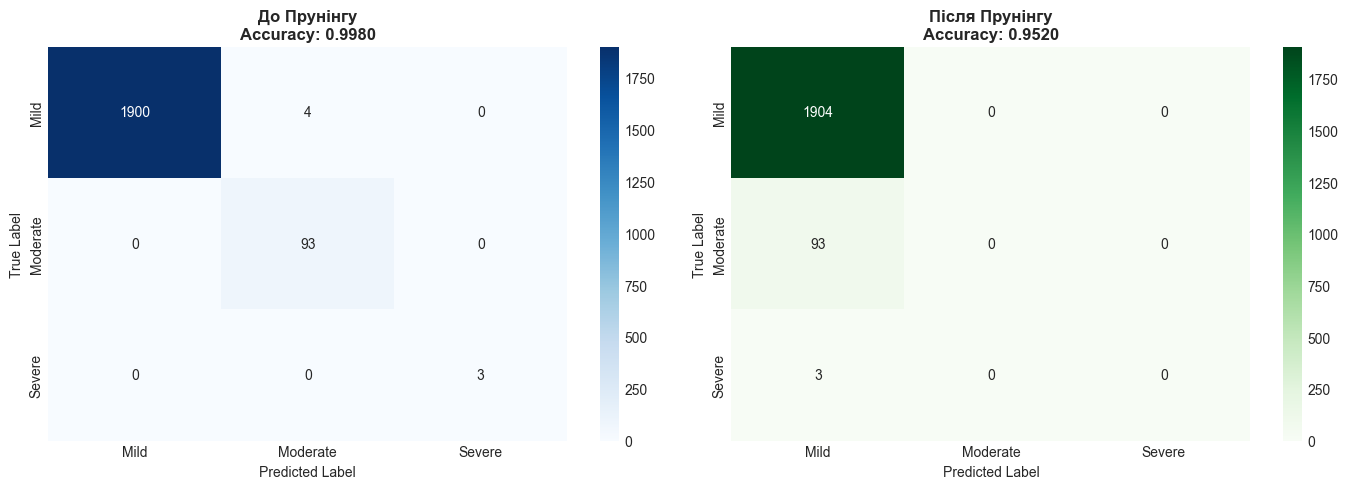

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До прунінгу
cm_before = confusion_matrix(y_test, y_pred_before)
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
axes[0].set_title(f'До Прунінгу\nAccuracy: {accuracy_before:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Після прунінгу
cm_after = confusion_matrix(y_test, y_pred_after)
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
axes[1].set_title(f'Після Прунінгу\nAccuracy: {accuracy_after:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Порівняємо власну реалізацію із sklearn DecisionTree. Навчаємо sklearn DecisionTree.

In [24]:
start_time = time.time()
dt_sklearn = DecisionTreeClassifier(criterion='gini', max_depth=10,
                                   min_samples_split=10, random_state=42)
dt_sklearn.fit(X_train, y_train)
train_time_sk = time.time() - start_time

print(f"\nsklearn DecisionTree навчено за {train_time_sk:.4f} секунд")


sklearn DecisionTree навчено за 0.0265 секунд


Прогнозуємо.

In [25]:
start_time = time.time()
y_pred_sk = dt_sklearn.predict(X_test)
predict_time_sk = time.time() - start_time

print(f"  Час прогнозування: {predict_time_sk:.4f} секунд")

  Час прогнозування: 0.0047 секунд


Виводимо метрики.

In [26]:
accuracy_sk = accuracy_score(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk, average='weighted')
mcc_sk = matthews_corrcoef(y_test, y_pred_sk)
cm_sk = confusion_matrix(y_test, y_pred_sk)

print(f"\nМЕТРИКИ sklearn DecisionTree:")
print(f"  Accuracy: {accuracy_sk:.4f}")
print(f"  F1-Score: {f1_sk:.4f}")
print(f"  MCC: {mcc_sk:.4f}")


МЕТРИКИ sklearn DecisionTree:
  Accuracy: 0.9975
  F1-Score: 0.9975
  MCC: 0.9732


Cross-validation:

In [27]:
cv_scores = cross_val_score(dt_sklearn, X_train, y_train, cv=5,
                           scoring='accuracy')
print(f"\n5-Fold Cross-Validation:")
print(f"  Scores: {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")



5-Fold Cross-Validation:
  Scores: [1.       1.       0.99875  0.998125 0.999375]
  Mean: 0.9992 (+/- 0.0015)


Виводимо матрицю невідповідностей.

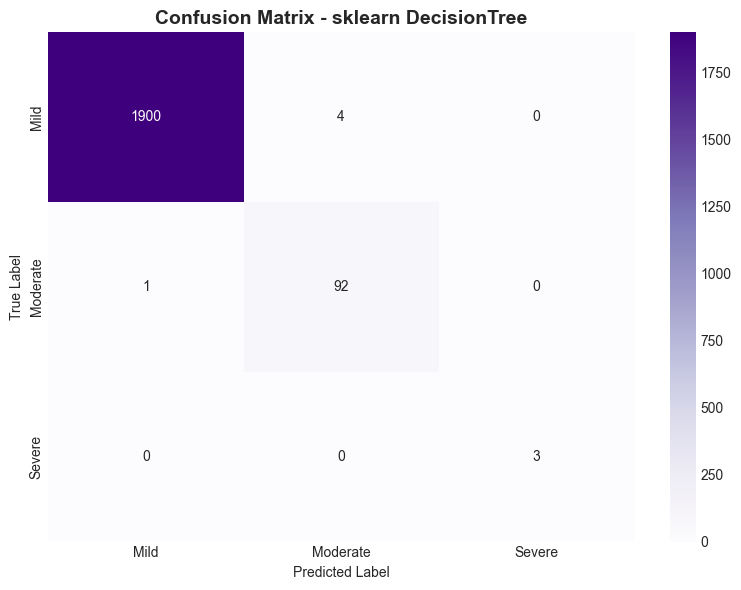

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - sklearn DecisionTree', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Візуалізація важливості ознак sklearn:

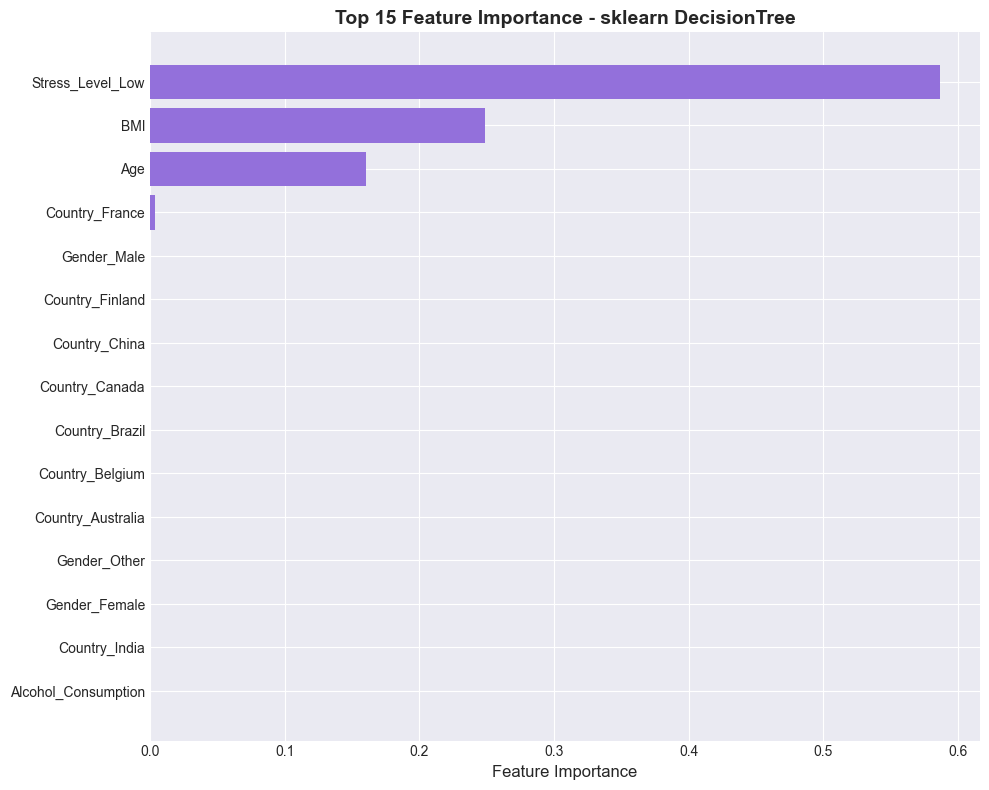

In [29]:
top_n = 15
indices_sk = np.argsort(dt_sklearn.feature_importances_)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices_sk)), dt_sklearn.feature_importances_[indices_sk],
         color='mediumpurple')
plt.yticks(range(len(indices_sk)), [feature_names[i] for i in indices_sk])
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Top {top_n} Feature Importance - sklearn DecisionTree',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Візьмемо ще для порівняння Random Forest - Ансамбль дерев. Навчаємо та прогнозуємо.

In [30]:
start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, criterion='gini',
                            max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
train_time_rf = time.time() - start_time

print(f"\nRandom Forest навчено за {train_time_rf:.4f} секунд")
print(f"  Кількість дерев: {rf.n_estimators}")


Random Forest навчено за 0.2088 секунд
  Кількість дерев: 100


In [31]:
start_time = time.time()
y_pred_rf = rf.predict(X_test)
predict_time_rf = time.time() - start_time

print(f"  Час прогнозування: {predict_time_rf:.4f} секунд")

  Час прогнозування: 0.0552 секунд


Виводимо метрики.

In [32]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\nМЕТРИКИ Random Forest:")
print(f"  Accuracy: {accuracy_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")
print(f"  MCC: {mcc_rf:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                          target_names=le_target.classes_))


МЕТРИКИ Random Forest:
  Accuracy: 0.9960
  F1-Score: 0.9953
  MCC: 0.9561

Classification Report:
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00      1904
    Moderate       0.95      0.97      0.96        93
      Severe       0.00      0.00      0.00         3

    accuracy                           1.00      2000
   macro avg       0.65      0.66      0.65      2000
weighted avg       0.99      1.00      1.00      2000



Cross-Validation:

In [33]:
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5,
                               scoring='accuracy')
print(f"\n5-Fold Cross-Validation:")
print(f"  Scores: {cv_scores_rf}")
print(f"  Mean: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")


5-Fold Cross-Validation:
  Scores: [0.995   0.99625 0.9925  0.99125 0.99125]
  Mean: 0.9933 (+/- 0.0041)


Виводимо матрицю невідповідностей.

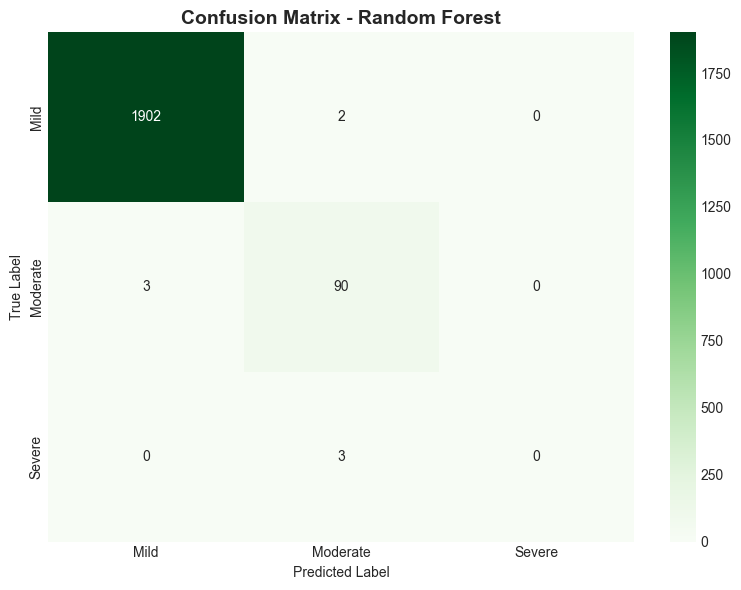

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Візуалізація важливості ознак Random Forest.

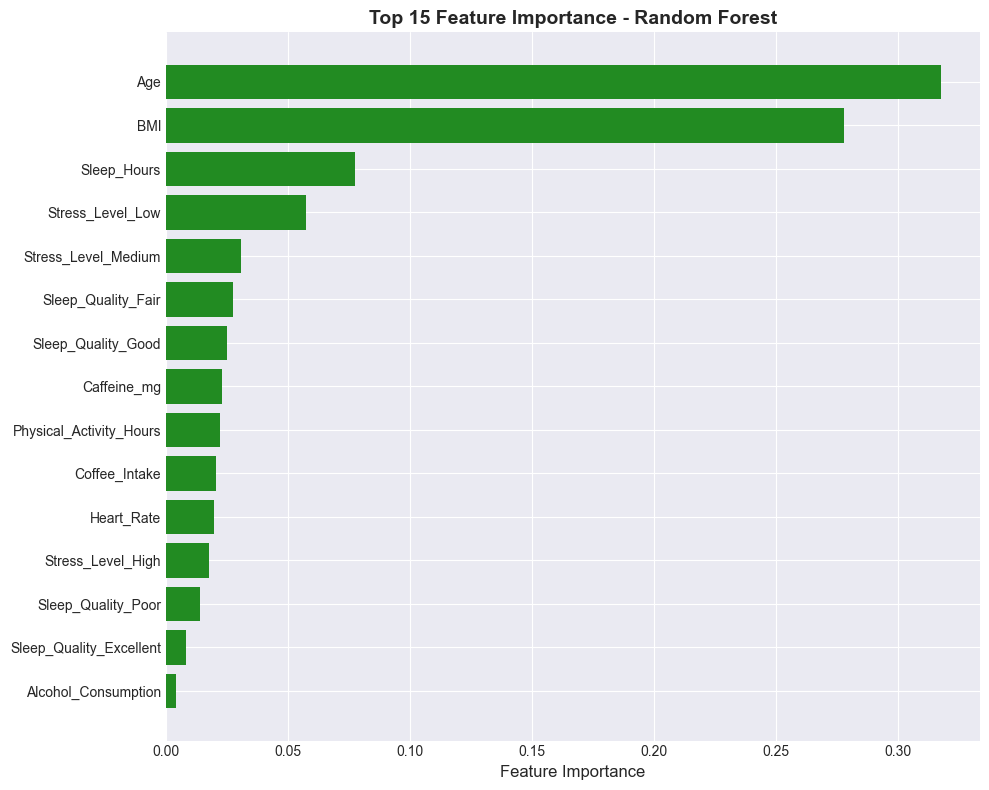

In [35]:
top_n = 15
indices_rf = np.argsort(rf.feature_importances_)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices_rf)), rf.feature_importances_[indices_rf],
         color='forestgreen')
plt.yticks(range(len(indices_rf)), [feature_names[i] for i in indices_rf])
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Top {top_n} Feature Importance - Random Forest',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Порівняємо усі моделі.

In [36]:
results = pd.DataFrame({
    'Model': ['MyDecisionTree', 'MyDT + Pruning', 'sklearn DT', 'Random Forest'],
    'Accuracy': [accuracy_my, accuracy_after, accuracy_sk, accuracy_rf],
    'F1-Score': [f1_my, f1_after, f1_sk, f1_rf],
    'MCC': [mcc_my, mcc_after, mcc_sk, mcc_rf],
    'Train Time (s)': [train_time, train_time, train_time_sk, train_time_rf]
})

print("\nЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ:")
print(results.to_string(index=False))


ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ:
         Model  Accuracy  F1-Score      MCC  Train Time (s)
MyDecisionTree    0.9980  0.998020 0.978799        2.408092
MyDT + Pruning    0.9520  0.928590 0.000000        2.408092
    sklearn DT    0.9975  0.997519 0.973214        0.026528
 Random Forest    0.9960  0.995272 0.956083        0.208754


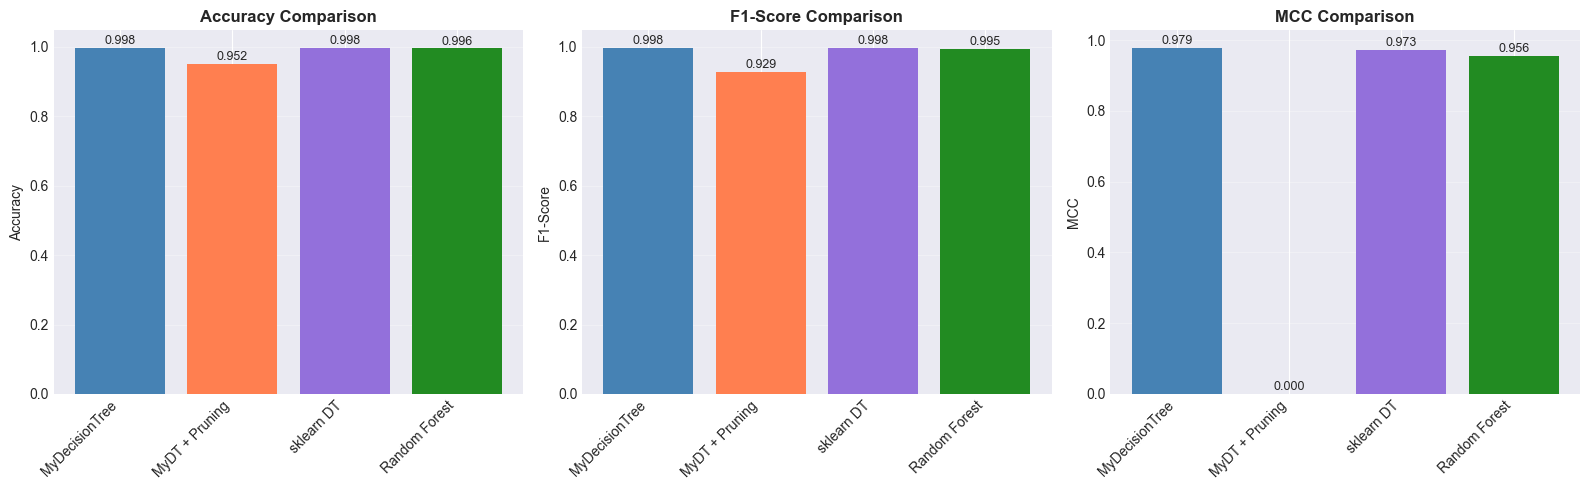

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Accuracy', 'F1-Score', 'MCC']
colors = ['steelblue', 'coral', 'mediumpurple', 'forestgreen']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric, fontsize=10)
    axes[i].set_xticklabels(results['Model'], rotation=45, ha='right')
    axes[i].grid(axis='y', alpha=0.3)

    # Додаємо значення на графік
    for j, v in enumerate(results[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

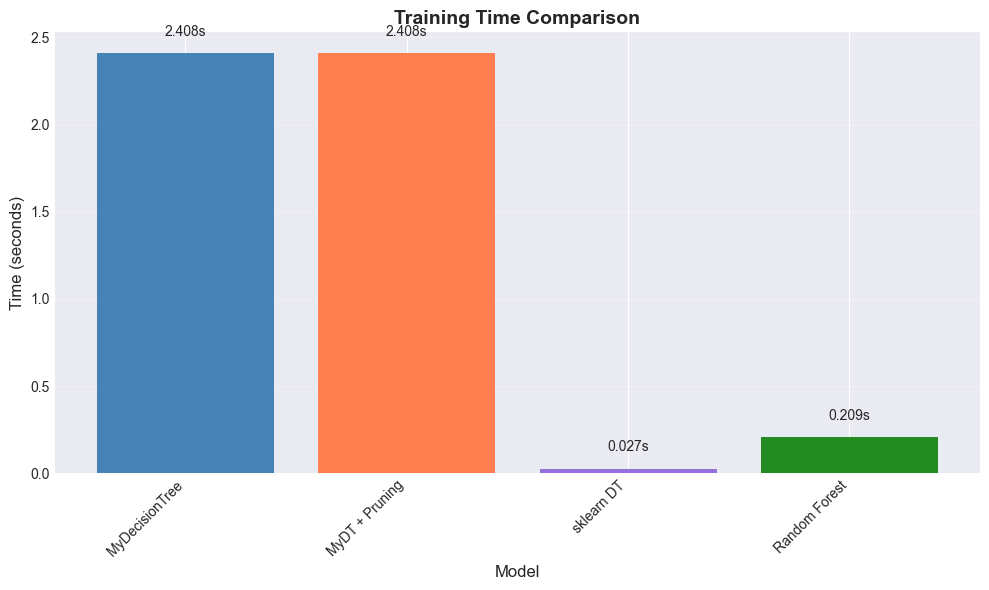

In [38]:
plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Train Time (s)'], color=colors)
plt.title('Training Time Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Time (seconds)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(results['Train Time (s)']):
    plt.text(i, v + 0.1, f'{v:.3f}s', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Проведемо інженерію ознак. Завантажуємо дані та обробляємо їх.

In [39]:
# Завантажуємо дані знову для інженерії
df_eng = pd.read_csv('synthetic_coffee_health_10000.csv')
if 'ID' in df_eng.columns:
    df_eng = df_eng.drop('ID', axis=1)

# Видаляємо рядки з NaN в цільовій змінній
print(f"Початковий розмір датасету: {df_eng.shape[0]} рядків")
df_eng = df_eng.dropna(subset=['Health_Issues'])
print(f"Після видалення NaN в Health_Issues: {df_eng.shape[0]} рядків")

# Заповнюємо NaN в інших колонках
if df_eng.isnull().sum().sum() > 0:
    print("\nЗаповнення пропущених значень в ознаках...")
    for col in df_eng.columns:
        if df_eng[col].isnull().sum() > 0:
            if df_eng[col].dtype in ['int64', 'float64']:
                df_eng[col].fillna(df_eng[col].median(), inplace=True)
            else:
                df_eng[col].fillna(df_eng[col].mode()[0], inplace=True)
    print("Пропущені значення заповнено")

X_eng = df_eng.drop('Health_Issues', axis=1)
y_eng = df_eng['Health_Issues']

print(f"Початкова кількість ознак: {X_eng.shape[1]}")

Початковий розмір датасету: 10000 рядків
Після видалення NaN в Health_Issues: 4059 рядків
Початкова кількість ознак: 14


Створюємо нові ознаки.

In [40]:
# Взаємодії між ключовими ознаками
if 'Coffee_Intake' in X_eng.columns and 'Sleep_Hours' in X_eng.columns:
    X_eng['Coffee_Sleep_Interaction'] = X_eng['Coffee_Intake'] * X_eng['Sleep_Hours']
    print("  ✓ Coffee_Sleep_Interaction")

if 'Coffee_Intake' in X_eng.columns and 'Caffeine_mg' in X_eng.columns:
    X_eng['Coffee_Caffeine_Ratio'] = X_eng['Caffeine_mg'] / (X_eng['Coffee_Intake'] + 1)
    print("  ✓ Coffee_Caffeine_Ratio")

if 'BMI' in X_eng.columns and 'Physical_Activity_Hours' in X_eng.columns:
    X_eng['BMI_Activity_Interaction'] = X_eng['BMI'] * X_eng['Physical_Activity_Hours']
    print("  ✓ BMI_Activity_Interaction")

if 'Heart_Rate' in X_eng.columns and 'Sleep_Hours' in X_eng.columns:
    X_eng['Heart_Sleep_Ratio'] = X_eng['Heart_Rate'] / (X_eng['Sleep_Hours'] + 1)
    print("  ✓ Heart_Sleep_Ratio")

  ✓ Coffee_Sleep_Interaction
  ✓ Coffee_Caffeine_Ratio
  ✓ BMI_Activity_Interaction
  ✓ Heart_Sleep_Ratio


In [41]:
# Квадратичні ознаки для важливих змінних
if 'Coffee_Intake' in X_eng.columns:
    X_eng['Coffee_Intake_Squared'] = X_eng['Coffee_Intake'] ** 2
    print("  ✓ Coffee_Intake_Squared")

if 'BMI' in X_eng.columns:
    X_eng['BMI_Squared'] = X_eng['BMI'] ** 2
    print("  ✓ BMI_Squared")

  ✓ Coffee_Intake_Squared
  ✓ BMI_Squared


Проводимо бінінг числових ознак.

In [42]:
if 'Age' in X_eng.columns:
    X_eng['Age_Binned'] = pd.cut(X_eng['Age'], bins=[18, 30, 50, 80],
                                 labels=['Young', 'Middle', 'Old'])
    print("  ✓ Age_Binned (Young, Middle, Old)")

if 'Coffee_Intake' in X_eng.columns:
    X_eng['Coffee_Level'] = pd.cut(X_eng['Coffee_Intake'], bins=[0, 2, 4, 10],
                                   labels=['Low', 'Medium', 'High'])
    print("  ✓ Coffee_Level (Low, Medium, High)")

if 'Sleep_Hours' in X_eng.columns:
    X_eng['Sleep_Category'] = pd.cut(X_eng['Sleep_Hours'], bins=[0, 6, 8, 12],
                                     labels=['Poor', 'Good', 'Excellent'])
    print("  ✓ Sleep_Category (Poor, Good, Excellent)")

  ✓ Age_Binned (Young, Middle, Old)
  ✓ Coffee_Level (Low, Medium, High)
  ✓ Sleep_Category (Poor, Good, Excellent)


Кодуємо категоріальні ознаки.

In [43]:
categorical_cols_eng = X_eng.select_dtypes(include=['object']).columns.tolist()
print(f"  Категоріальні ознаки: {categorical_cols_eng}")

# One-hot encoding
X_eng_encoded = pd.get_dummies(X_eng, columns=categorical_cols_eng, drop_first=False)

print(f"\nКількість ознак після інженерії: {X_eng_encoded.shape[1]}")
print(f"  Приріст: +{X_eng_encoded.shape[1] - X_eng.shape[1]} ознак")

  Категоріальні ознаки: ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation']

Кількість ознак після інженерії: 53
  Приріст: +30 ознак


Кореляційний аналіз та видалення високо корельованих ознак.

In [44]:
# Обчислюємо кореляцію тільки для числових ознак
numeric_cols = X_eng_encoded.select_dtypes(include=[np.number]).columns
correlation_matrix = X_eng_encoded[numeric_cols].corr().abs()

# Знаходимо пари з високою кореляцією (>0.9)
upper_triangle = np.triu(np.ones_like(correlation_matrix), k=1).astype(bool)
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] > 0.9:
            high_corr_pairs.append((correlation_matrix.columns[i],
                                   correlation_matrix.columns[j],
                                   correlation_matrix.iloc[i, j]))

if high_corr_pairs:
    print(f"  Знайдено {len(high_corr_pairs)} пар високо корельованих ознак (r > 0.9):")
    for feat1, feat2, corr in high_corr_pairs[:5]:  # Показуємо перші 5
        print(f"    {feat1} <-> {feat2}: {corr:.3f}")

    # Видаляємо одну ознаку з кожної пари
    to_drop = set([pair[1] for pair in high_corr_pairs])
    X_eng_encoded = X_eng_encoded.drop(columns=list(to_drop))
    print(f"  Видалено {len(to_drop)} високо корельованих ознак")
else:
    print("  Не знайдено високо корельованих ознак")

print(f"\nФінальна кількість ознак: {X_eng_encoded.shape[1]}")

  Знайдено 7 пар високо корельованих ознак (r > 0.9):
    Coffee_Intake <-> Caffeine_mg: 1.000
    Coffee_Intake <-> Coffee_Sleep_Interaction: 0.928
    Coffee_Intake <-> Coffee_Intake_Squared: 0.949
    Caffeine_mg <-> Coffee_Sleep_Interaction: 0.928
    Caffeine_mg <-> Coffee_Intake_Squared: 0.949
  Видалено 5 високо корельованих ознак

Фінальна кількість ознак: 48


Нормалізуємо числові ознаки.

In [45]:
numeric_features = X_eng_encoded.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_eng_encoded[numeric_features] = scaler.fit_transform(X_eng_encoded[numeric_features])

print(f"  Нормалізовано {len(numeric_features)} числових ознак")

  Нормалізовано 10 числових ознак


Обробляємо дані.

In [46]:
# Конвертуємо ВСІ колонки в числовий формат
print("\nКонвертація всіх колонок в числовий формат...")
for col in X_eng_encoded.columns:
    if X_eng_encoded[col].dtype == 'object' or X_eng_encoded[col].dtype == 'bool':
        # Для булевих та об'єктних колонок
        X_eng_encoded[col] = X_eng_encoded[col].astype(float)

# Перевіряємо, що всі колонки числові
non_numeric = X_eng_encoded.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"  Залишилися нечислові колонки: {non_numeric}")
    # Примусово конвертуємо
    for col in non_numeric:
        X_eng_encoded[col] = pd.to_numeric(X_eng_encoded[col], errors='coerce')
        X_eng_encoded[col].fillna(0, inplace=True)
else:
    print(f"  Всі {X_eng_encoded.shape[1]} колонок тепер числові")

# Переконуємося, що немає NaN після конвертації
if X_eng_encoded.isnull().sum().sum() > 0:
    print("  Виявлено NaN після конвертації, заповнюємо нулями...")
    X_eng_encoded.fillna(0, inplace=True)


Конвертація всіх колонок в числовий формат...
  Залишилися нечислові колонки: ['Age_Binned', 'Coffee_Level', 'Sleep_Category']


Готуємо дані до навчання.

In [47]:
# Кодуємо цільову змінну
y_eng_encoded = le_target.transform(y_eng)

# Зберігаємо назви ознак
feature_names_eng = X_eng_encoded.columns.tolist()

# Розділяємо на train/test
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng_encoded.values, y_eng_encoded, test_size=0.2,
    random_state=42, stratify=y_eng_encoded
)

Проведемо відбір найважливіших ознак. Спершу переконуємося що дані готові.

In [48]:
# Перевіряємо тип даних
print(f"\nПеревірка типів даних:")
print(f"  X_train_eng тип: {type(X_train_eng)}, форма: {X_train_eng.shape}")
print(f"  y_train_eng тип: {type(y_train_eng)}, dtype: {y_train_eng.dtype}")
print(f"  Приклад y_train_eng: {y_train_eng[:5]}")

# Переконуємося, що y - це числовий масив
if not np.issubdtype(y_train_eng.dtype, np.number):
    print("\ny_train_eng не числовий! Конвертуємо...")
    y_train_eng = y_train_eng.astype(int)
    y_test_eng = y_test_eng.astype(int)
    print(f"Конвертовано. Новий dtype: {y_train_eng.dtype}")


Перевірка типів даних:
  X_train_eng тип: <class 'numpy.ndarray'>, форма: (3247, 48)
  y_train_eng тип: <class 'numpy.ndarray'>, dtype: int32
  Приклад y_train_eng: [0 0 0 0 0]


Навчаємо дерево на всіх ознаках після інженерії.

In [49]:
print("\nНавчання дерева на всіх ознаках...")
tree_for_selection = MyDecisionTree(max_depth=10, min_samples=10)
tree_for_selection.fit(X_train_eng, y_train_eng)


Навчання дерева на всіх ознаках...


In [50]:
y_pred_all = tree_for_selection.predict(X_test_eng)
accuracy_all = accuracy_score(y_test_eng, y_pred_all)
f1_all = f1_score(y_test_eng, y_pred_all, average='weighted')

print(f"\nМетрики на ВСІХ ознаках ({len(feature_names_eng)} ознак):")
print(f"  Accuracy: {accuracy_all:.4f}")
print(f"  F1-Score: {f1_all:.4f}")


Метрики на ВСІХ ознаках (48 ознак):
  Accuracy: 0.9951
  F1-Score: 0.9950


Відбираємо топ-k ознак за importance.

In [51]:
# Визначаємо поріг або кількість ознак
importance_threshold = 0.01
top_k = 20

# Метод 1: За порогом
selected_by_threshold = tree_for_selection.feature_importance > importance_threshold
n_selected_threshold = np.sum(selected_by_threshold)

# Метод 2: Топ-k
indices_top_k = np.argsort(tree_for_selection.feature_importance)[-top_k:]

print(f"\n  Метод 1 (importance > {importance_threshold}): {n_selected_threshold} ознак")
print(f"  Метод 2 (топ-{top_k}): {top_k} ознак")


  Метод 1 (importance > 0.01): 3 ознак
  Метод 2 (топ-20): 20 ознак


In [52]:
# Використовуємо топ-k метод
selected_features_idx = indices_top_k
selected_features_names = [feature_names_eng[i] for i in selected_features_idx]

print(f"\nВідібрано {len(selected_features_names)} ознак:")
for i, (idx, name) in enumerate(zip(selected_features_idx, selected_features_names), 1):
    print(f"  {i}. {name}: {tree_for_selection.feature_importance[idx]:.4f}")


Відібрано 20 ознак:
  1. Physical_Activity_Hours: 0.0000
  2. Smoking: 0.0000
  3. Alcohol_Consumption: 0.0000
  4. Coffee_Caffeine_Ratio: 0.0000
  5. Heart_Sleep_Ratio: 0.0000
  6. Country_France: 0.0000
  7. Age_Binned: 0.0000
  8. Sleep_Category: 0.0000
  9. Gender_Female: 0.0000
  10. Gender_Male: 0.0000
  11. Gender_Other: 0.0000
  12. Country_Australia: 0.0000
  13. Country_Belgium: 0.0000
  14. Country_Brazil: 0.0000
  15. Country_Canada: 0.0000
  16. Country_China: 0.0000
  17. Coffee_Level: 0.0000
  18. Age: 0.1219
  19. BMI: 0.2316
  20. Stress_Level_Low: 0.6465


Створюємо датасет з відібраними ознаками

In [53]:
# Створюємо датасет з відібраними ознаками
X_train_selected = X_train_eng[:, selected_features_idx]
X_test_selected = X_test_eng[:, selected_features_idx]

Навчаємо моделі на відібраних ознаках.

In [54]:
tree_selected = MyDecisionTree(max_depth=10, min_samples=10)
tree_selected.fit(X_train_selected, y_train_eng)
y_pred_selected = tree_selected.predict(X_test_selected)

accuracy_selected = accuracy_score(y_test_eng, y_pred_selected)
f1_selected = f1_score(y_test_eng, y_pred_selected, average='weighted')
mcc_selected = matthews_corrcoef(y_test_eng, y_pred_selected)

print(f"\nMyDecisionTree на відібраних ознаках:")
print(f"  Accuracy: {accuracy_selected:.4f} (зміна: {accuracy_selected-accuracy_all:+.4f})")
print(f"  F1-Score: {f1_selected:.4f} (зміна: {f1_selected-f1_all:+.4f})")
print(f"  MCC: {mcc_selected:.4f}")


MyDecisionTree на відібраних ознаках:
  Accuracy: 0.9951 (зміна: +0.0000)
  F1-Score: 0.9950 (зміна: +0.0000)
  MCC: 0.9763


In [55]:
rf_selected = RandomForestClassifier(n_estimators=100, max_depth=10,
                                    random_state=42, n_jobs=-1)
rf_selected.fit(X_train_selected, y_train_eng)
y_pred_rf_selected = rf_selected.predict(X_test_selected)

accuracy_rf_selected = accuracy_score(y_test_eng, y_pred_rf_selected)
f1_rf_selected = f1_score(y_test_eng, y_pred_rf_selected, average='weighted')

print(f"\nRandom Forest на відібраних ознаках:")
print(f"  Accuracy: {accuracy_rf_selected:.4f}")
print(f"  F1-Score: {f1_rf_selected:.4f}")


Random Forest на відібраних ознаках:
  Accuracy: 0.9889
  F1-Score: 0.9870


Обчислюємо Permutation Importance.

In [56]:
perm_importance = permutation_importance(
    tree_selected, X_test_selected, y_test_eng,
    n_repeats=10, random_state=42, n_jobs=-1
)

Сортуємо за важливістю.

In [57]:
# Сортуємо за importance
perm_indices = np.argsort(perm_importance.importances_mean)[::-1]

print(f"\nТоп-10 ознак за Permutation Importance:")
for i in range(min(10, len(perm_indices))):
    idx = perm_indices[i]
    print(f"  {i+1}. {selected_features_names[idx]}: "
          f"{perm_importance.importances_mean[idx]:.4f} "
          f"(±{perm_importance.importances_std[idx]:.4f})")


Топ-10 ознак за Permutation Importance:
  1. Age: 0.2262 (±0.0108)
  2. Stress_Level_Low: 0.2070 (±0.0106)
  3. BMI: 0.1618 (±0.0060)
  4. Gender_Female: 0.0000 (±0.0000)
  5. Smoking: 0.0000 (±0.0000)
  6. Alcohol_Consumption: 0.0000 (±0.0000)
  7. Coffee_Caffeine_Ratio: 0.0000 (±0.0000)
  8. Heart_Sleep_Ratio: 0.0000 (±0.0000)
  9. Country_France: 0.0000 (±0.0000)
  10. Age_Binned: 0.0000 (±0.0000)


Візуалізуємо порівняння.

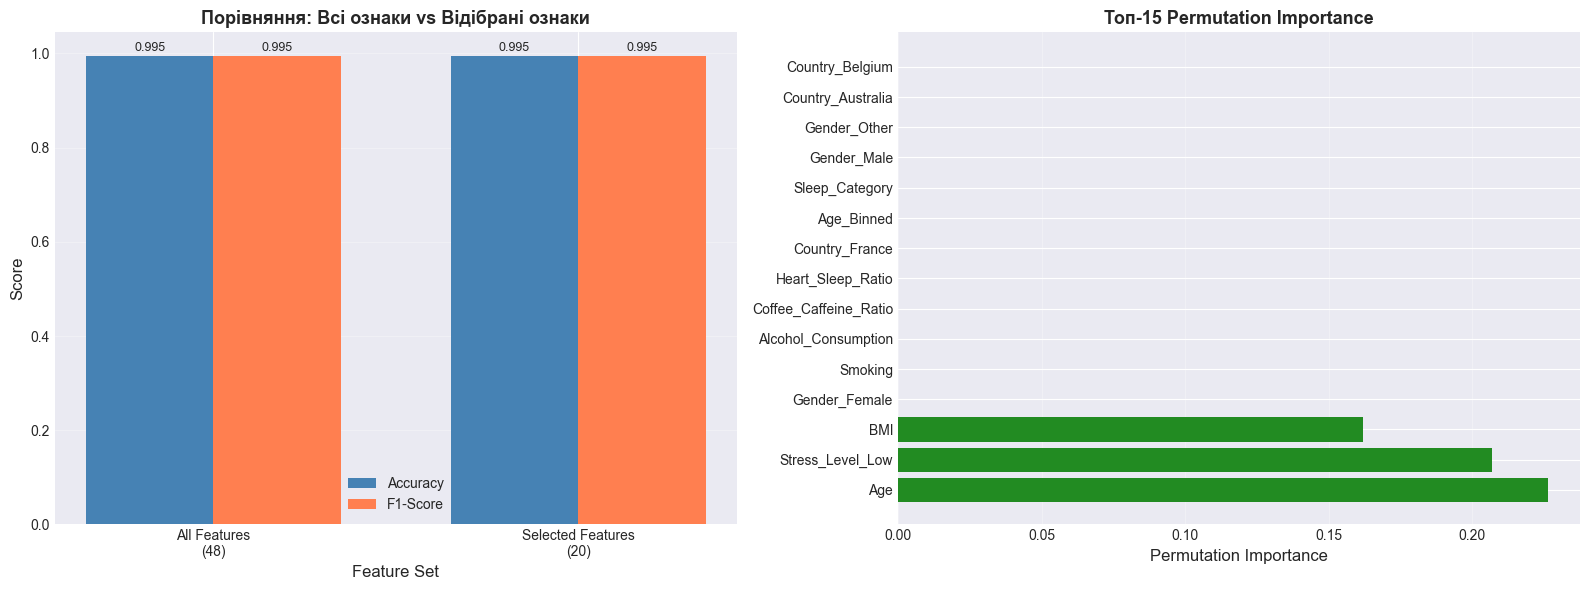

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Порівняння метрик
models_comp = ['All Features\n' + f'({len(feature_names_eng)})',
               'Selected Features\n' + f'({len(selected_features_names)})']
accuracy_comp = [accuracy_all, accuracy_selected]
f1_comp = [f1_all, f1_selected]

x_pos = np.arange(len(models_comp))
width = 0.35

axes[0].bar(x_pos - width/2, accuracy_comp, width, label='Accuracy', color='steelblue')
axes[0].bar(x_pos + width/2, f1_comp, width, label='F1-Score', color='coral')
axes[0].set_xlabel('Feature Set', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Порівняння: Всі ознаки vs Відібрані ознаки',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models_comp)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Додаємо значення
for i, (acc, f1) in enumerate(zip(accuracy_comp, f1_comp)):
    axes[0].text(i - width/2, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=9)

# Permutation Importance
top_perm = min(15, len(perm_indices))
axes[1].barh(range(top_perm),
             perm_importance.importances_mean[perm_indices[:top_perm]],
             color='forestgreen')
axes[1].set_yticks(range(top_perm))
axes[1].set_yticklabels([selected_features_names[i] for i in perm_indices[:top_perm]])
axes[1].set_xlabel('Permutation Importance', fontsize=12)
axes[1].set_title(f'Топ-{top_perm} Permutation Importance',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Виводимо фінальну таблицю результатів.

In [59]:
final_results = pd.DataFrame({
    'Модель': [
        'MyDecisionTree (базова)',
        'MyDecisionTree + Pruning',
        'sklearn DecisionTree',
        'Random Forest',
        'MyDT + Feature Engineering',
        'RF + Feature Engineering'
    ],
    'Кількість ознак': [
        len(feature_names),
        len(feature_names),
        len(feature_names),
        len(feature_names),
        len(selected_features_names),
        len(selected_features_names)
    ],
    'Accuracy': [
        accuracy_my,
        accuracy_after,
        accuracy_sk,
        accuracy_rf,
        accuracy_selected,
        accuracy_rf_selected
    ],
    'F1-Score': [
        f1_my,
        f1_after,
        f1_sk,
        f1_rf,
        f1_selected,
        f1_rf_selected
    ]
})

print("\nФІНАЛЬНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ:")
print(final_results.to_string(index=False))


ФІНАЛЬНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ:
                    Модель  Кількість ознак  Accuracy  F1-Score
   MyDecisionTree (базова)               44  0.998000  0.998020
  MyDecisionTree + Pruning               44  0.952000  0.928590
      sklearn DecisionTree               44  0.997500  0.997519
             Random Forest               44  0.996000  0.995272
MyDT + Feature Engineering               20  0.995074  0.995027
  RF + Feature Engineering               20  0.988916  0.986994


Виводимо найкращу модель – наша базова реалізація.

In [60]:
best_model_idx = final_results['Accuracy'].idxmax()
best_model_name = final_results.loc[best_model_idx, 'Модель']
best_accuracy = final_results.loc[best_model_idx, 'Accuracy']

print(f"\nНАЙКРАЩА МОДЕЛЬ: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")


НАЙКРАЩА МОДЕЛЬ: MyDecisionTree (базова)
   Accuracy: 0.9980


Виводимо детальніші порівняння у графіках.

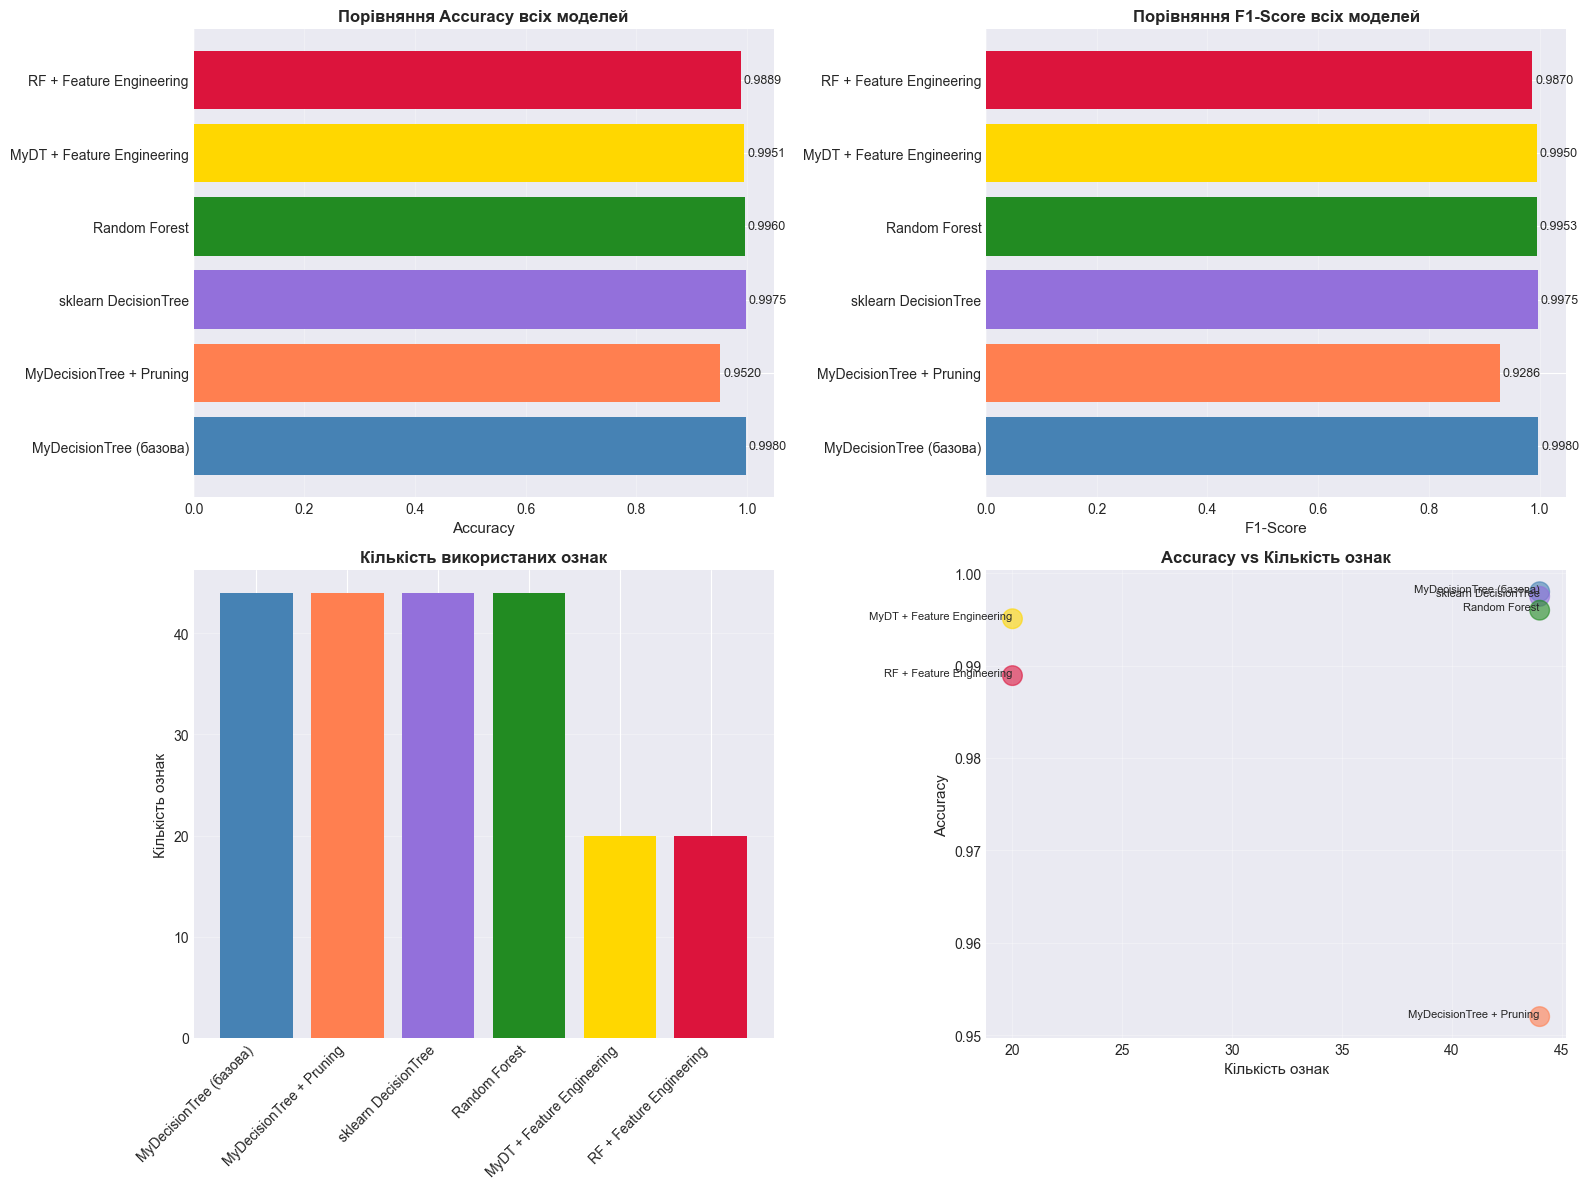

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Порівняння Accuracy
axes[0, 0].barh(final_results['Модель'], final_results['Accuracy'],
                color=['steelblue', 'coral', 'mediumpurple', 'forestgreen',
                       'gold', 'crimson'])
axes[0, 0].set_xlabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Порівняння Accuracy всіх моделей',
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(final_results['Accuracy']):
    axes[0, 0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# 2. Порівняння F1-Score
axes[0, 1].barh(final_results['Модель'], final_results['F1-Score'],
                color=['steelblue', 'coral', 'mediumpurple', 'forestgreen',
                       'gold', 'crimson'])
axes[0, 1].set_xlabel('F1-Score', fontsize=11)
axes[0, 1].set_title('Порівняння F1-Score всіх моделей',
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(final_results['F1-Score']):
    axes[0, 1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# 3. Кількість ознак
axes[1, 0].bar(range(len(final_results)), final_results['Кількість ознак'],
               color=['steelblue', 'coral', 'mediumpurple', 'forestgreen',
                      'gold', 'crimson'])
axes[1, 0].set_xticks(range(len(final_results)))
axes[1, 0].set_xticklabels(final_results['Модель'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Кількість ознак', fontsize=11)
axes[1, 0].set_title('Кількість використаних ознак',
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Accuracy vs Кількість ознак
axes[1, 1].scatter(final_results['Кількість ознак'], final_results['Accuracy'],
                   s=200, c=['steelblue', 'coral', 'mediumpurple', 'forestgreen',
                            'gold', 'crimson'], alpha=0.6)
for i, txt in enumerate(final_results['Модель']):
    axes[1, 1].annotate(txt,
                       (final_results['Кількість ознак'].iloc[i],
                        final_results['Accuracy'].iloc[i]),
                       fontsize=8, ha='right')
axes[1, 1].set_xlabel('Кількість ознак', fontsize=11)
axes[1, 1].set_ylabel('Accuracy', fontsize=11)
axes[1, 1].set_title('Accuracy vs Кількість ознак',
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()